# Assignment 1. Exploratory Modeling with JUSTICE

**Course:** EPA141A Model Based Decision Making — Delft University of Technology  
**Model:** JUSTICE
**Contact:** J.ZatarainSalazar@tudelft.nl  

---

## Learning Outcomes

After completing this assignment you will be able to:
1. Verify that the JUSTICE model is installed and runs correctly.
2. Identify and define **model input uncertainties**.
3. Use **Latin Hypercube Sampling** to generate a scenario ensemble that spans the uncertainty space.
4. Run JUSTICE across many scenarios under different policy assumptions and collect the outcomes.
5. Visualise outcome **distributions**, **pair plots**, and **time series envelopes** to characterise how uncertainty propagates.


---

## Background

When building models of complex systems (climate, economy, ecology) we rarely know
the exact value of every parameter. A damage-function coefficient, a discount rate,
or a climate sensitivity parameter are all uncertain. **Exploratory modeling** treats
uncertainty explicitly: we run *many* scenarios, sampling the uncertain parameters
systematically, and study the resulting spread in model outputs.

In this assignment we treat four parameters as uncertain:

| Symbol | Parameter | Default | Range | Description |
|--------|-----------|---------|-------|-------------|
| `ρ` | Pure rate of social time preference | 0.015 | [0.001, 0.030] | Contested in the Stern–Nordhaus debate |
| `η` | Elasticity of marginal utility | 1.45 | [0.5, 1.5] | Empirical estimates range widely |
| `δ` | Damage function scale factor | 1.0 | [0.5, 2.0] | Structural uncertainty in damage estimates |
| `ecs_ensemble` | FaIR ensemble member index | 1 | [1, 1001] | Selects a calibrated ECS parameter set |

`ecs_ensemble` is a *physical* uncertainty (how sensitive the climate system is to CO₂),
while `ρ`, `η`, and `δ` are *normative* uncertainties (contested values in economic ethics).

We also compare two **policies** that differ in their emission control rate:

| Policy | `ecr_plateau` | Description |
|--------|--------------|-------------|
| `no_abatement` | 0.0 | Zero mitigation effort throughout the simulation |
| `moderate_abatement` | 0.4 | 40 % emission reduction applied from the start |

---

## Step 0 — Verify your installation

Run the cell below. Every line should end with ✓.  
If any line shows ✗, follow the installation instructions in setup_and_orientation.html

In [1]:
import importlib, sys
required = ["justice", "numpy", "pandas", "matplotlib",
            "ema_workbench", "scipy", "seaborn"]
for pkg in required:
    found = importlib.util.find_spec(pkg) is not None
    print(f"  {'✓' if found else '✗'}  {pkg}")
print(f"\nPython {sys.version.split()[0]}")

  ✓  justice
  ✓  numpy
  ✓  pandas
  ✓  matplotlib
  ✓  ema_workbench
  ✓  scipy
  ✓  seaborn

Python 3.12.13


## Setup — Imports and model configuration

The cell below imports all required packages and applies a Python 3.14 compatibility patch for `matplotlib.path.Path.__deepcopy__`. It also configures EMA Workbench logging and defines the shared name lists for outcomes, parameters, and policies that are referenced throughout the notebook.

## Step 1 — Run JUSTICE with default parameters

Before exploring uncertainty, confirm the model runs with its default settings. Run the cell before anything else, it loads all required packages and defines shared name lists used throughout the notebook.


**Task 1.1** —  the `justice_model` function below does the following:
1. Hard-reset JUSTICE and instantiate a fresh model with the given `ecs_ensemble` index.
2. Set `rho` on `model.welfare_function.pure_rate_of_social_time_preference`.
3. Set `eta` on `model.welfare_function.elasticity_of_marginal_utility_of_consumption`.
4. Scale the three active damage coefficients (`coefficient_a`, `coefficient_b`, `damage_gdp_ratio_with_gradient`) by `delta`.
5. Run with zero abatement (`ECR = 0`) and return all four outcomes as a dict.

> **Note:** Default argument values are required by the EMA Workbench function model interface.

**Task 1.2** — Run the default case (`ecs_ensemble=1`, all other parameters at their defaults) and record the four outcome values.

In [2]:
import os, sys
# ── Add JUSTICE-main to sys.path so justice internal imports resolve ───────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_justice_root = os.path.normpath(os.path.join(_NOTEBOOK_DIR, '../JUSTICE-main'))

_PLOTS_DIR = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)
if _justice_root not in sys.path:
    sys.path.insert(0, _justice_root)
os.chdir(_justice_root)

import warnings; warnings.filterwarnings("ignore")
import logging
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from ema_workbench import (
    Model, RealParameter, ScalarOutcome, ArrayOutcome,
    perform_experiments, ema_logging, Sample,
    SequentialEvaluator, MultiprocessingEvaluator,
)
from justice.model import JUSTICE
from justice.util.enumerations import WelfareFunction
from justice.objectives.objective_functions import years_above_temperature_threshold

ema_logging.log_to_stderr(logging.WARNING)   # suppress per-run INFO noise

OBJECTIVES   = ["welfare", "years_above_temperature_threshold",
                "welfare_loss_damage", "welfare_loss_abatement"]
PARAMS       = ["rho", "eta", "delta", "ecs_ensemble"]
POLICY_NAMES = ["no_abatement", "moderate_abatement"]

print("Imports OK")
import matplotlib.path as _mpath
def _patched_path_deepcopy(self, memo=None):
    if memo is None: memo = {}
    new_path = _mpath.Path.__new__(_mpath.Path)
    memo[id(self)] = new_path
    verts = self._vertices.copy()
    codes = self._codes.copy() if self._codes is not None else None
    new_path.__init__(verts, codes,
                      _interpolation_steps=self._interpolation_steps, readonly=False)
    return new_path
_mpath.Path.__deepcopy__ = _patched_path_deepcopy

Imports OK


In [3]:
def justice_model(rho=0.015, eta=1.45, delta=1.0, ecs_ensemble=1, ecr_plateau=0.0):
    """EMA Workbench function model — configurable abatement, Utilitarian welfare.

    Parameters
    ----------
    ecr_plateau : float
        Emission control rate applied uniformly across all regions and timesteps.
        0.0 = no abatement; 0.4 = 40% abatement (moderate policy).
    """
    JUSTICE.hard_reset()
    ensemble_idx = int(np.round(np.clip(ecs_ensemble, 1, 1001)))
    model = JUSTICE(
        start_year=2015, end_year=2300, timestep=1,
        scenario=2, climate_ensembles=ensemble_idx, stochastic_run=False,
        social_welfare_function=WelfareFunction.UTILITARIAN,
    )
    model.economy.pure_rate_of_social_time_preference = float(rho)
    model.economy.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.welfare_function.pure_rate_of_social_time_preference = float(rho)
    model.welfare_function.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.damage_function.coefficient_a                  *= float(delta)
    model.damage_function.coefficient_b                  *= float(delta)
    model.damage_function.damage_gdp_ratio_with_gradient *= float(delta)

    ecr = np.full(model.emission_control_rate.shape[:2], float(ecr_plateau))
    model.run(emission_control_rate=ecr, endogenous_savings_rate=True)
    datasets = model.evaluate()

    welfare = float(np.abs(np.squeeze(datasets["welfare"])))
    yat     = float(np.squeeze(
        years_above_temperature_threshold(datasets["global_temperature"], 2.0)
    ))
    _, _, _, wl_dmg = model.welfare_function.calculate_welfare(
        datasets["damage_cost_per_capita"], welfare_loss=True)
    _, _, _, wl_abt = model.welfare_function.calculate_welfare(
        datasets["abatement_cost_per_capita"], welfare_loss=True)

    # Global mean temperature trajectory (shape: n_timesteps)
    temp = np.squeeze(datasets["global_temperature"])
    if temp.ndim == 2:
        temp = temp.mean(axis=0)
    temperature_trajectory = temp.astype(float)

    return {
        "welfare":                          welfare,
        "years_above_temperature_threshold": yat,
        "welfare_loss_damage":              float(np.abs(np.squeeze(wl_dmg))),
        "welfare_loss_abatement":           float(np.abs(np.squeeze(wl_abt))),
        "temperature_trajectory":           temperature_trajectory,
    }

# Smoke test
test = justice_model()
for k, v in test.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: array shape {v.shape}, range [{v.min():.2f}, {v.max():.2f}]")
    else:
        print(f"  {k}: {v:.4f}")


  welfare: 103.7211
  years_above_temperature_threshold: 259.0000
  welfare_loss_damage: 3980.5410
  welfare_loss_abatement: 74364.1321
  temperature_trajectory: array shape (286,), range [1.20, 6.01]


## Step 2 — Define uncertain parameters

**Task 2.1** — Complete the cell below by:
1. Creating a `Model` object wrapping `justice_model`.
2. Assigning `uncertainties` — four `RealParameter` objects matching the table in the Background.
3. Assigning `outcomes` — four `ScalarOutcome` objects.

**Task 2.2** — Explain in 2–3 sentences why a *higher* pure rate of time preference `ρ` tends to lead to *less* stringent near-term mitigation. Reference the Ramsey rule in your answer.

A higher `ρ` means that the present has a higher value compared to the future. Meaning future gains are less important than present gains. Near-term mitigation has high future payoffs but right now it will cost a lot of money, which reduces near-term payoffs. So if rho is high, the present is valued more than the future, therefore near-term mitigation is probably less stringent.

**Task 2.3** — Explain why `ecs_ensemble` is a *physical* uncertainty while `ρ`, `η`, `δ` are *normative* uncertainties. What does this distinction imply about which outcomes each type of uncertainty can influence?

Ecs_ensemble is something that we do not know but it is defined by nature, it is uncertain but a fact so a value that we can not determine/change ourselves. Rho, eta and delta all concern our perception of economic mechanisms/value, they are something that we can change as humans but are uncertain. The economic/welfare outcomes can be changed by the normative uncertainties. The temperature outcomes can be changed by the physical uncertainty. 

In [4]:
em_model = Model('JUSTICE', function=justice_model)

em_model.uncertainties = [
    RealParameter('rho',          0.001, 0.030),  # Pure rate of social time preference
    RealParameter('eta',          0.5,   1.5  ),  # Elasticity of marginal utility
    RealParameter('delta',        0.5,   2.0  ),  # Damage function scale factor
    RealParameter('ecs_ensemble', 1,     1001 ),  # FaIR ensemble member index
]

# Policy lever: emission control rate applied uniformly across all timesteps
em_model.levers = [
    RealParameter('ecr_plateau', 0.0, 1.0),
]

em_model.outcomes = [
    ScalarOutcome('welfare'),
    ScalarOutcome('years_above_temperature_threshold'),
    ScalarOutcome('welfare_loss_damage'),
    ScalarOutcome('welfare_loss_abatement'),
    ArrayOutcome('temperature_trajectory'),
]

print(f"Uncertainties : {[u.name for u in em_model.uncertainties]}")
print(f"Levers        : {[l.name for l in em_model.levers]}")
print(f"Outcomes      : {[o.name for o in em_model.outcomes]}")


Uncertainties : ['rho', 'eta', 'delta', 'ecs_ensemble']
Levers        : ['ecr_plateau']
Outcomes      : ['welfare', 'years_above_temperature_threshold', 'welfare_loss_damage', 'welfare_loss_abatement', 'temperature_trajectory']


## Step 3 — Latin Hypercube Sampling ensemble

**Latin Hypercube Sampling (LHS)** divides each uncertain dimension into equally
probable intervals and samples exactly once from each interval. Compared to Monte Carlo,
it guarantees better coverage of the full parameter space with fewer samples.

You first need to define two policies to compare: one with no abatement (ecr_plateau=0.0) and one with moderate abatement (ecr_plateau=0.4). Use Sample to give each policy a name.

`perform_experiments` uses LHS by default. A single call handles sampling, execution, and result collection.

**Task 3.1** — Run 100 scenarios using `SequentialEvaluator`. Store the results as:
- `experiments` — a DataFrame with one row per scenario and one column per parameter
- `outcomes` — a dict mapping outcome names to arrays

In [5]:
import ema_workbench.em_framework.points as pts
print(dir(pts))

['CategoricalParameter', 'Counter', 'Experiment', 'ExperimentReplication', 'Generator', 'IntegerParameter', 'Iterable', 'Literal', 'NamedDict', 'NamedObject', 'NumpySeedLike', 'Parameter', 'ParameterMap', 'RNGLike', 'Sample', 'SampleCollection', 'TYPE_CHECKING', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_logger', 'annotations', 'combine', 'experiment_generator', 'flatten_sample', 'from_experiments', 'get_module_logger', 'itertools', 'math', 'np', 'overload', 'pd', 'platypus', 'sample', 'sample_generator', 'zip_cycle']


In [6]:
import inspect
from ema_workbench import Sample
print(inspect.getsource(Sample))

class Sample(NamedDict):
    """A point in parameter space."""

    id_counter = Counter(1)
    name_counter = Counter(0)

    def __init__(self, name=None, unique_id=None, **kwargs):
        if name is None:
            name = Sample.name_counter()
        if unique_id is None:
            unique_id = Sample.id_counter()

        super().__init__(name, **kwargs)
        self.unique_id = unique_id

    def __repr__(self):  # noqa D105
        return f"Sample({super().__repr__()})"

    def _to_platypus_solution(
        self, problem: Problem
    ) -> platypus.Solution:
        """Turn a Sample into a Platypus solution."""
        # fixme needs to handle latent variables correctly
        solution = platypus.Solution(problem)

        values = flatten_sample(self, problem.decision_variables)
        values = [dtype.encode(value) for dtype, value in zip(problem.types, values)]
        solution.variables[:] = values

        return solution

    @classmethod
    def _from_platypus_soluti

In [7]:
import ema_workbench
print(dir(ema_workbench))

['ArrayOutcome', 'BooleanParameter', 'CategoricalParameter', 'Constant', 'Constraint', 'EMAError', 'EpsilonIndicatorMetric', 'GenerationalDistanceMetric', 'HypervolumeMetric', 'IntegerParameter', 'InvertedGenerationalDistanceMetric', 'IpyparallelEvaluator', 'MPIEvaluator', 'Model', 'MultiprocessingEvaluator', 'OutputSpaceExplorationAlgorithm', 'Problem', 'RealParameter', 'ReplicatorModel', 'Sample', 'Samplers', 'ScalarOutcome', 'SequentialEvaluator', 'SpacingMetric', 'TimeSeriesOutcome', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'em_framework', 'ema_logging', 'epsilon_nondominated', 'load_archives', 'load_results', 'optimize', 'perform_experiments', 'process_replications', 'save_results', 'util']


In [8]:
import inspect
from ema_workbench.em_framework.points import ExperimentReplication
print(inspect.getsource(ExperimentReplication))

class ExperimentReplication(NamedDict):
    """Helper class that combines scenario, policy, any constants, and replication information.

    This class represent the complete specification of parameters to run for
    a given experiment.

    """

    def __init__(self, scenario, policy, constants, replication=None):
        scenario_id = scenario.unique_id
        policy_id = policy.unique_id

        if replication is None:
            replication_id = 1
        else:
            replication_id = replication.id
            constants = combine(constants, replication)

        # this is a unique identifier for an experiment
        # we might also create a better looking name
        self.id = scenario_id * policy_id * replication_id
        name = f"{scenario.name}_{policy.name}_{replication_id}"

        super().__init__(name, **combine(scenario, policy, constants))



In [9]:
print(inspect.getsource(ema_workbench.em_framework.points.NamedDict))

class NamedDict(MutableMapping, NamedObject):
    """Named dictionary class."""

    def __init__(self, name=representation, **kwargs):
        super().__init__(name)
        self.data = {**kwargs}
        if name is None:
            raise ValueError()
        elif callable(name):
            name = name(self)
        self.name = name

    def copy(self):
        """Return a shallow copy of this object."""
        return copy.copy(self)

    def __getitem__(self, key):  # noqa: D105
        return self.data[key]

    def __setitem__(self, key, value):  # noqa: D105
        self.data[key] = value

    def __delitem__(self, key):  # noqa: D105
        del self.data[key]

    def __iter__(self) -> Iterator:  # noqa: D105
        return iter(self.data)

    def __len__(self) -> int:  # noqa: D105
        return len(self.data)

    def __or__(self, other):  # noqa: D105
        if not isinstance(other, Mapping | dict):
            raise NotImplementedError
        new = self.copy()
       

In [10]:
from ema_workbench.em_framework.points import Counter
print(inspect.getsource(Counter))

class Counter:
    """helper function for generating counter based names for NamedDicts."""

    def __init__(self, startfrom=0):
        self._counter = itertools.count(startfrom)

    def __call__(self, *args):  # noqa: D102
        return next(self._counter)



In [11]:
policies = [
    Sample(name='no_abatement',       ecr_plateau=0.0),
    Sample(name='moderate_abatement', ecr_plateau=0.4),
]

# tqdm compatibility fix for Python ≥ 3.14 (not needed on the course environment)
import tqdm as _tqdm_mod
if _tqdm_mod.tqdm is not _tqdm_mod.std.tqdm:
    _tqdm_mod.tqdm = _tqdm_mod.std.tqdm

# Note: MultiprocessingEvaluator gives large speed-ups for 500+ scenarios when
# run from a script (python run_experiments.py). Inside a Jupyter notebook the
# spawned worker processes cannot reliably re-import the venv, so we use
# SequentialEvaluator here. For script-based runs, swap the context manager.
with SequentialEvaluator(em_model) as evaluator:
    experiments, outcomes = evaluator.perform_experiments(
        scenarios=100,
        policies=policies,
    )

df_results = pd.DataFrame({k: v for k, v in outcomes.items() if k != 'temperature_trajectory'})
df_params  = experiments[PARAMS]
df_results['policy'] = experiments['policy'].values

print(f"Ensemble complete: {len(experiments)} runs  "
      f"({df_results['policy'].value_counts().to_dict()})")
print(df_results[OBJECTIVES].agg(['min', 'median', 'max']).round(2).to_string())

100%|████████████████████████████████████████| 200/200 [11:14<00:00,  3.37s/it]

Ensemble complete: 200 runs  ({'moderate_abatement': 100, 'no_abatement': 100})
           welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
min          59.11                              176.0                 9.09                    1.52
median      434.21                              242.0               780.41                  488.86
max     2612361.92                              264.0           2612829.31              2614847.68


## Step 4 — Visualise outcome distributions

**Task 4.1** — Run the cell below. It plots the distribution of each outcome across your 100 LHS scenarios, separately for each policy. The red dashed line is the model's default output (all parameters at their reference values).

Look at the four plots and answer:

Which outcomes show a wide spread? What does that tell you about uncertainty?
Does the distribution shift between the two policies? For which outcomes?
Where does the default (red line) sit relative to the distributions — is it typical or an outlier?

Most of the outcomes show quite some spread, meaning that there is a lot of uncertainty. When applying the policies the outcomes of years above temperature threshold and the welfare loss abatement are really wide spread. The welfare and welfare loss damage are pretty similar. That means that the policies have most influence on those factors.

Most of the default scenarios are outliers opposed to the policies.

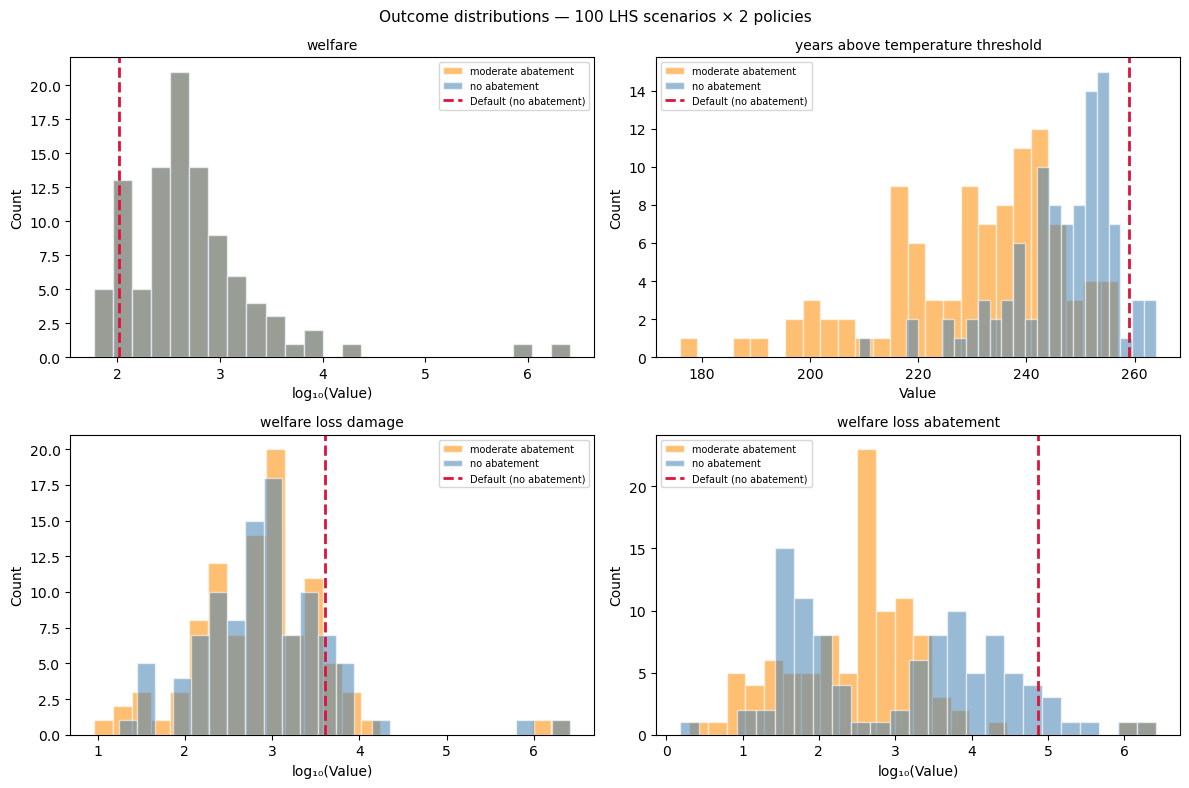

In [12]:
defaults = justice_model()

palette = {'no_abatement': 'steelblue', 'moderate_abatement': 'darkorange'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, obj in zip(axes.flat, OBJECTIVES):
    for pol, grp in df_results.groupby('policy'):
        data = grp[obj]
        use_log = (data.max() / (data.min() + 1e-12)) > 100
        vals = np.log10(data + 1e-12) if use_log else data
        ax.hist(vals, bins=25, color=palette[pol], edgecolor='white',
                alpha=0.55, label=pol.replace('_', ' '))
    ax.axvline(
        np.log10(defaults[obj] + 1e-12) if use_log else defaults[obj],
        color='crimson', lw=2, ls='--', label='Default (no abatement)',
    )
    ax.set_xlabel('log₁₀(Value)' if use_log else 'Value')
    ax.set_title(obj.replace('_', ' '), fontsize=10)
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

fig.suptitle("Outcome distributions — 100 LHS scenarios × 2 policies", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, "a01ema_outcome_distributions.png"), dpi=150, bbox_inches='tight')
plt.show()


## Step 5 — Outcome pair plots

Run the cell below. It produces a pair plot: every outcome plotted against every other outcome, coloured by policy.

Look at the plot and answer:

Which pairs of outcomes move together (are correlated)? Which don't?
Do the two policies separate clearly in any of the panels, or do they overlap?
What does it mean for decision-making if two outcomes are strongly correlated?


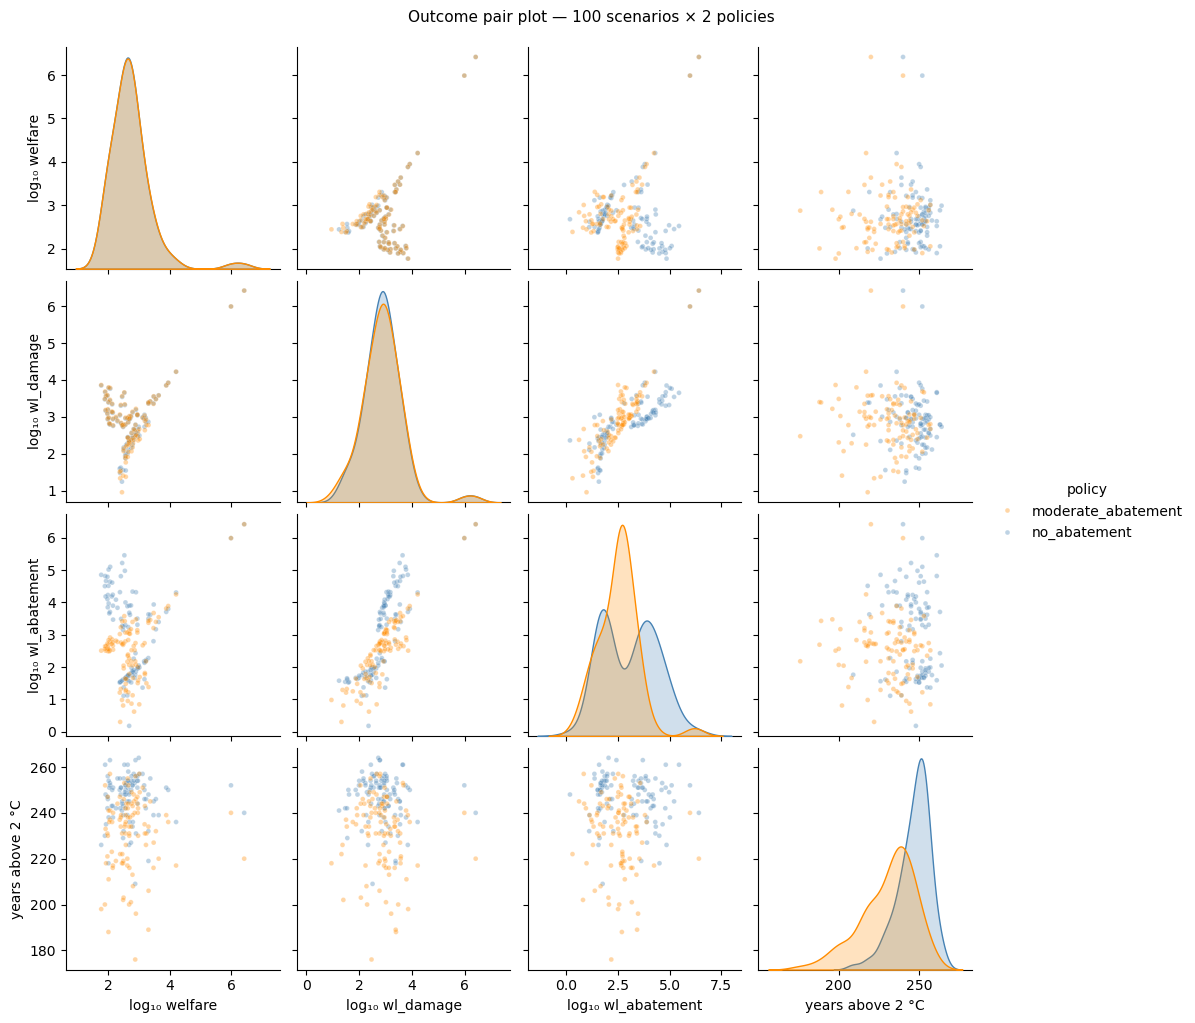

Saved: a01ema_outcome_pairplot.png


In [13]:
df_outcomes_plot = df_results[OBJECTIVES + ['policy']].copy()

for col in ['welfare_loss_damage', 'welfare_loss_abatement', 'welfare']:
    df_outcomes_plot[col] = np.log10(df_outcomes_plot[col] + 1e-9)

log_labels = {
    'welfare': 'log₁₀ welfare',
    'welfare_loss_damage': 'log₁₀ wl_damage',
    'welfare_loss_abatement': 'log₁₀ wl_abatement',
    'years_above_temperature_threshold': 'years above 2 °C',
}
df_outcomes_plot.rename(columns=log_labels, inplace=True)
plot_vars = list(log_labels.values())

g = sns.pairplot(
    df_outcomes_plot, vars=plot_vars,
    hue='policy', palette=palette,
    plot_kws={'alpha': 0.35, 's': 12}, diag_kind='kde',
)
g.fig.suptitle("Outcome pair plot — 100 scenarios × 2 policies", y=1.02, fontsize=11)
plt.savefig(os.path.join(_PLOTS_DIR, "a01ema_outcome_pairplot.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: a01ema_outcome_pairplot.png")


WL abatement and WL damage are pretty correlated. WL damage nd welfare are really correlated.

The policies overlap for welfare and damage, which means that these outcome metrics are indifferent to the policies. Years above temperature threshold and abatement do show big differences.

## Step 6 — Temperature trajectory envelope

Run the cell below. It plots the temperature trajectory for all 100 scenarios as an ensemble envelope: the median line, the interquartile range (dark band), and the 5–95th percentile range (light band).

Look at the plot and answer:

At year 2100, does the moderate abatement policy reliably stay below 2 °C, or does uncertainty still push some trajectories above the threshold?
How wide is the envelope at 2100 compared to 2050? What drives that widening?
If you were advising a policymaker, what would you tell them about the 2 °C target based on this plot?


At 2100 most of the moderate abatement policy envelope is above 2 degrees actually, maybe even all. The envelope is a lot wider, probably due to uncertainties increasing as we look further into the future.

I would tell a policymaker that the 2*C target is not realistic with the currently tested policies. They have to either set lower targets or invest more in abatement.

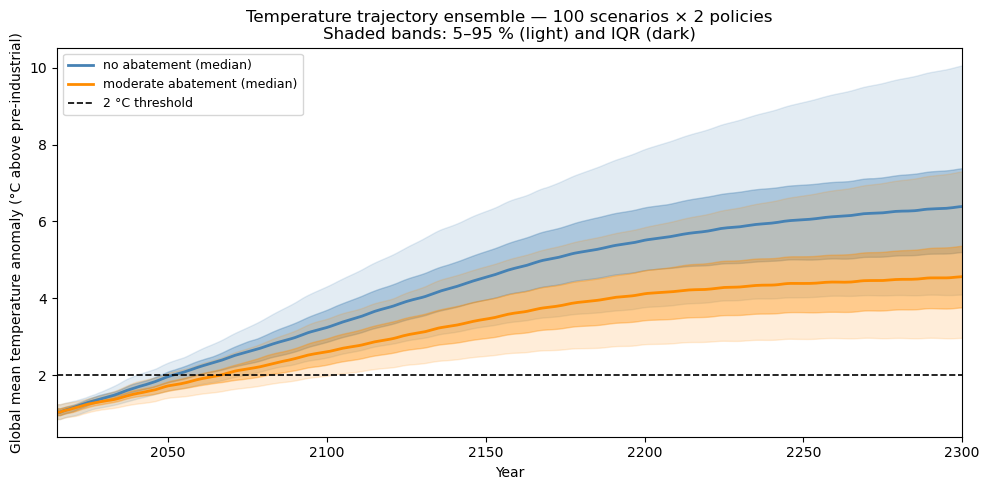

Saved: a01ema_temperature_envelope.png


In [15]:
temp_all = outcomes['temperature_trajectory']
policy_col = experiments['policy'].values
n_timesteps = temp_all.shape[1]
years = np.arange(2015, 2015 + n_timesteps)

fig, ax = plt.subplots(figsize=(10, 5))

for pol, colour in palette.items():
    mask = policy_col == pol
    traj = temp_all[mask]
    med  = np.median(traj, axis=0)
    p25  = np.percentile(traj, 25, axis=0)
    p75  = np.percentile(traj, 75, axis=0)
    p05  = np.percentile(traj,  5, axis=0)
    p95  = np.percentile(traj, 95, axis=0)
    ax.fill_between(years, p05, p95, alpha=0.15, color=colour)
    ax.fill_between(years, p25, p75, alpha=0.35, color=colour)
    ax.plot(years, med, color=colour, lw=2, label=pol.replace('_', ' ') + ' (median)')

ax.axhline(2.0, color='black', lw=1.2, ls='--', label='2 °C threshold')
ax.set_xlabel('Year')
ax.set_ylabel('Global mean temperature anomaly (°C above pre-industrial)')
ax.set_title('Temperature trajectory ensemble — 100 scenarios × 2 policies\n'
             'Shaded bands: 5–95 % (light) and IQR (dark)')
ax.legend(fontsize=9)
ax.set_xlim(years[0], years[-1])

# run the code below if you want to save the images in the plot directory
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, "a01ema_temperature_envelope.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: a01ema_temperature_envelope.png")


## Reflection Questions

**1. Coverage vs. efficiency.** Why does LHS typically need fewer samples than simple random (Monte Carlo) sampling to achieve the same coverage of the parameter space?

Because the LHS does it in a structured way, making sure that the sample space is divided into similar parts and one sample from each subspace is taken. This ensures a high efficiency while covering the entire space. Monte Carlo uses random sampling, this might result in it taking a long time before it has achieved the same coverage.

**2. Default as reference.** In your histogram plots, does the default run fall near the centre of the distribution or near one of the tails? What does this imply about how representative a single default run is?

Near the tails. It tells us that a single default run is not that reliable/representative as it is really a momentary snapshot and there are a lot of uncertainties.

**3. Propagation of uncertainty.** Which of the four outcomes shows the widest relative spread? Propose a hypothesis explaining why that outcome is more sensitive to the chosen uncertain parameters.

Welfare loss abatement, as this is influenced by every chosen uncertainty except for the physical. Moreover it is pretty directly influenced by the two policy options.
